# Validation of the filtered units: contamination, unimodality, classification

`F23` compares the new selection against the original one, but it does not test
whether either produces a population of well isolated single units. That is what
this notebook does.

Three questions:

**1. Does the surviving population behave like single units?** A pooled
interspike interval histogram should show a clear refractory dip, and individual
units should show one too.

**2. Do the units that were removed look worse on measures that were not used to
remove them?** This is the part that carries weight. A criterion cannot validate
itself, so the comparison uses only metrics that are computed but not
thresholded: the waveform shape heterogeneity, the amplitude mode separation,
the within-burst amplitude attenuation, and the waveform consistency. If the
discarded units score worse on these, the filtering removed something real.

**3. Are the unit properties unimodal?** A population of well isolated single
units should show unimodal distributions of waveform width and height within a
class. Bimodality would suggest the class still mixes distinct populations.

Units are classified into the six waveform classes along the way, using the
project's own classification functions rather than a reimplementation, so the
assignment matches the rest of the analysis exactly.

In [1]:
import os
os.chdir('/CSNG/studekat/ripple_paper_clean_copy/code')

In [2]:
from functions_analysis import *
import pandas as pd, numpy as np, yaml, pickle, neo
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import zscore
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)

with open("/CSNG/studekat/ripple_paper_clean_copy/code/params_analysis.yml") as f:
    P = yaml.safe_load(f)

DF_FOLDER = '/CSNG/studekat/ripple_paper_clean_copy/dataframes'
CONDITIONS = {'RS':    ('L N F'.split(), P['data_folder']),}
              #'NATIM': ('N F'.split(),   P['natim_data_folder'])}
COND_COL = {'RS': 'tab:green', 'NATIM': 'tab:purple'}

FINAL_CLASSES  = P['final_classes']
CLASS_COLORS   = P['colors_class']
WIDTH_INTERVALS = P['width_intervals']
PEAK_HEIGHT    = P['first_peak_height']
CLASS_DICT = {'DOWN_narrow_shallow':'NarrBI','DOWN_narrow_sharp':'NarrTRI',
              'DOWN_wide':'Wide','DOWN_medium_shallow':'MedBI',
              'DOWN_medium_sharp':'MedTRI','UP':'Pos'}
KEY = ['monkey','date','array','cell_name']

# ISI histogram, computed while loading so spike times need not be held
ISI_MAX_S, ISI_BIN_S = 0.050, 0.0005
ISI_EDGES = np.arange(0, ISI_MAX_S + ISI_BIN_S, ISI_BIN_S)
ISI_CENTRES = (ISI_EDGES[:-1] + ISI_EDGES[1:]) / 2

MAX_RECORDINGS = None      # set a small number for a first pass

## 1. Load the filtered files

Spike times are used only to build a per-unit interspike interval histogram and
are then discarded, so memory stays low. The mean waveform and its z-scored form
are read from the annotations.

In [3]:
##### SPIKE FILE PATHS #####
#     spikes_KS4/{stem}_Array{N}_spikes_KS4.nix             earlier filtering
#     spikes_KS4/{stem}_Array{N}_spikes_KS4_unfiltered.nix  every sorted unit
#     spikes_filtered/{stem}_Array{N}_spikes_KS4_filtered.nix   this filtering

def recording_folder(monkey, date, type_rec, data_folder):
    """The recording directory, which differs between the two paradigms."""
    if type_rec == 'NATIM':
        return f'{data_folder}/macaque{monkey}_TVSD_{date}'
    return f'{data_folder}/macaque{monkey}_{type_rec}_{date}'


def file_stem(monkey, date, type_rec):
    """The filename prefix, again paradigm dependent."""
    if type_rec == 'NATIM':
        return f'macaque{monkey}_TVSD_{date}'
    return f'macaque{monkey}_{type_rec}_{date}'


def spike_path(monkey, date, array, type_rec, data_folder, kind='all'):
    """
    Path to one array's spike file.

    kind is 'all' for every sorted unit, 'good' for the earlier filtering, or
    'filtered' for the output of this filtering. Returns None if absent.
    """
    base = recording_folder(monkey, date, type_rec, data_folder)
    stem = file_stem(monkey, date, type_rec)
    sub, suf = {'all':      ('spikes_KS4',      'spikes_KS4_unfiltered'),
                'good':     ('spikes_KS4',      'spikes_KS4'),
                'filtered': ('spikes_filtered', 'spikes_KS4_filtered')}[kind]
    p = f'{base}/{sub}/{stem}_Array{array}_{suf}.nix'
    return p if os.path.isfile(p) else None


def all_units_path(monkey, date, array, type_rec, data_folder):
    return spike_path(monkey, date, array, type_rec, data_folder, kind='all')


def good_units_path(monkey, date, array, type_rec, data_folder):
    return spike_path(monkey, date, array, type_rec, data_folder, kind='good')


def filtered_path(monkey, date, array, type_rec, data_folder):
    return spike_path(monkey, date, array, type_rec, data_folder, kind='filtered')


def annot(st, key, default=np.nan):
    """Read an annotation, converting the string 'NaN' back to a numeric NaN."""
    v = st.annotations.get(key, default)
    if isinstance(v, str) and v.strip().lower() == 'nan':
        return np.nan
    return v


def load_filtered(type_rec, monkeys, data_folder, max_rec=None):
    rows, isis = [], []
    n_rec = 0
    for m in monkeys:
        for date in P['dates'][m][type_rec]:
            if max_rec is not None and n_rec >= max_rec:
                break
            found = False
            for array in range(1, 17):
                p = filtered_path(m, date, array, type_rec, data_folder)
                if p is None:
                    continue
                found = True
                try:
                    io = neo.NixIO(p, 'ro'); blk = io.read_block()
                    for st in blk.segments[0].spiketrains:
                        t = np.sort(np.asarray(
                            st.times.rescale('s').magnitude, dtype=float))
                        d = {'monkey': m, 'date': date, 'array': array,
                             'cell_name': annot(st, 'nix_name', ''),
                             'condition': type_rec,
                             'n_spikes': len(t),
                             'Electrode_ID': annot(st, 'Electrode_ID'),
                             'area': annot(st, 'Area', 'unknown')}
                        for k in ['flt_FR_computed','flt_viol_ratio_1p5ms',
                                  'flt_coinc_ratio_worst','flt_wf_shape_pc1_modesep',
                                  'flt_wf_snr_computed','flt_amp_mode_separation',
                                  'flt_amp_cv','flt_atten_index','flt_wf_corr_p05',
                                  'flt_presence_ratio_computed']:
                            d[k.replace('flt_','')] = annot(st, k)
                        w = annot(st, 'avg_wf', None)
                        wz = annot(st, 'avg_wf_zscored', None)
                        d['avg_wf'] = np.asarray(w, dtype=float) if w is not None \
                                      and not isinstance(w, str) else None
                        d['avg_wf_zscored'] = np.asarray(wz, dtype=float) \
                            if wz is not None and not isinstance(wz, str) else None
                        # ISI histogram now, spike times discarded after
                        if len(t) >= 2:
                            isi = np.diff(t)
                            h = np.histogram(isi[isi < ISI_MAX_S], bins=ISI_EDGES)[0]
                            isis.append(h.astype(float))
                            d['n_isi'] = int((isi < ISI_MAX_S).sum())
                            d['isi_total'] = int(len(isi))
                        else:
                            isis.append(np.zeros(len(ISI_CENTRES)))
                            d['n_isi'] = 0; d['isi_total'] = 0
                        rows.append(d)
                    io.close(); del blk
                except Exception as e:
                    print(f'   {m} {date} array {array}: {e}')
            if found:
                n_rec += 1
    if not rows:
        return None, None
    return pd.DataFrame(rows), np.vstack(isis)


DATA, ISI = {}, {}
for tr, (monkeys, data_folder) in CONDITIONS.items():
    print(f'loading {tr} ...')
    d, h = load_filtered(tr, monkeys, data_folder, MAX_RECORDINGS)
    if d is None:
        print(f'   nothing found; has SUA_write_filtered_nix.py run for {tr}?')
        continue
    DATA[tr], ISI[tr] = d, h
    print(f'   {len(d)} units from {d.groupby(["monkey","date"]).ngroups} recordings')
    print(f'   with a mean waveform: {int(d["avg_wf"].notna().sum())}')

loading RS ...
   2574 units from 7 recordings
   with a mean waveform: 2574


## 2. Classify into the six waveform classes

Using the project's own functions, so the assignment is identical to the one
used elsewhere. The chain adds waveform width and amplitude, the z-scored
waveform, the width class, the up or down direction, and finally the six-way
class from the width class and the height of the first peak.

In [4]:
def classify(df):
    """
    Run the project's classification chain on a frame carrying avg_wf.

    aux_add_zscored_avg_waveform expects a quantity with a .magnitude, so the
    stored z-scored waveform is used directly where available and recomputed
    otherwise. The recomputation matches: their function applies scipy's zscore
    to the averaged waveform, which is what the filtering script stored.
    """
    d = df[df['avg_wf'].notna()].copy()
    d = aux_add_waveform_prop(d)
    if d['avg_wf_zscored'].isna().any():
        miss = d['avg_wf_zscored'].isna()
        d.loc[miss, 'avg_wf_zscored'] = [zscore(w) for w in d.loc[miss, 'avg_wf']]
    d['amp_wf_zscored'] = [np.max(w) - np.min(w) for w in d['avg_wf_zscored']]
    d = aux_add_width_classes(d, width_intervals=WIDTH_INTERVALS)
    d = aux_add_up_down_classes(d)
    d = aux_add_final_classes(d, final_classes=FINAL_CLASSES,
                              peak_height_th=PEAK_HEIGHT)
    d['first_peak_height'] = [first_peak_height_from_waveform(w)
                              for w in d['avg_wf_zscored']]
    return d

for tr in list(DATA):
    n0 = len(DATA[tr])
    DATA[tr] = classify(DATA[tr])
    ISI[tr] = ISI[tr][:len(DATA[tr])] if len(DATA[tr]) == n0 else ISI[tr]
    print(f'{tr}: classified {len(DATA[tr])} of {n0} units')
    print(DATA[tr]['final_class'].value_counts().rename(index=CLASS_DICT).to_string())
    n_nc = int((DATA[tr]['final_class'] == 'NO_CLASS').sum())
    if n_nc:
        print(f'   {n_nc} unclassified')
    print()

RS: classified 2574 of 2574 units
final_class
Wide       927
MedBI      788
NarrBI     291
MedTRI     265
NarrTRI    212
Pos         91



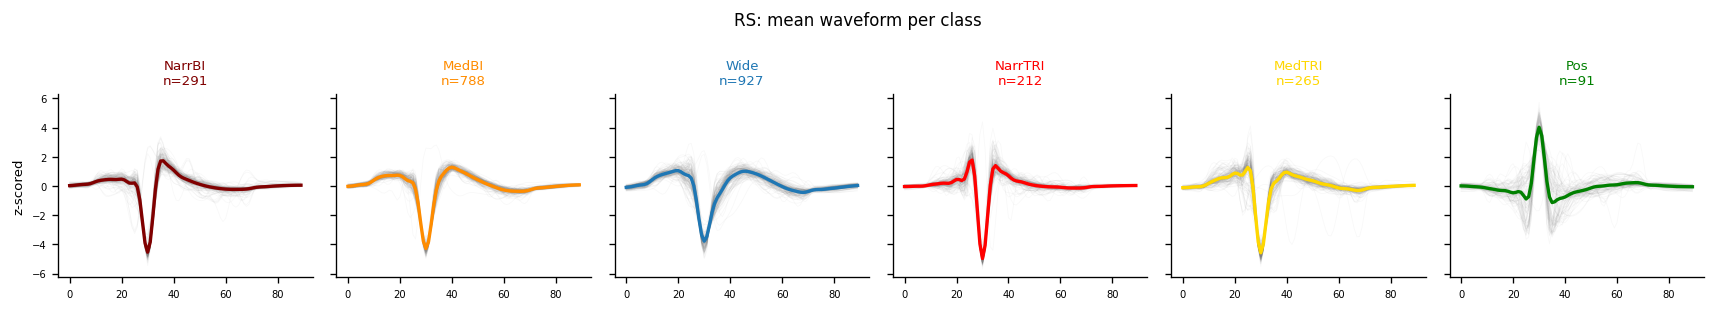

In [5]:
# average waveform per class, to confirm the assignment looks right
for tr, d in DATA.items():
    present = [c for c in FINAL_CLASSES if (d['final_class'] == c).any()]
    fig, axes = plt.subplots(1, len(present), figsize=(2.4*len(present), 2.6),
                             dpi=120, sharey=True)
    axes = np.atleast_1d(axes)
    for ax, cl in zip(axes, present):
        sub = d[d['final_class'] == cl]
        W = np.vstack(sub['avg_wf_zscored'].values)
        for w in W[np.random.default_rng(0).choice(
                len(W), min(150, len(W)), replace=False)]:
            ax.plot(w, color='gray', alpha=0.05, lw=0.5)
        ax.plot(W.mean(axis=0), color=CLASS_COLORS[cl], lw=2)
        ax.set_title(f'{CLASS_DICT[cl]}\nn={len(sub)}', fontsize=8,
                     color=CLASS_COLORS[cl])
        ax.tick_params(labelsize=6)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    axes[0].set_ylabel('z-scored', fontsize=8)
    fig.suptitle(f'{tr}: mean waveform per class', fontsize=10)
    plt.tight_layout(); plt.show()

## 3. Does the population behave like single units?

The pooled interspike interval histogram, and the per-unit refractory dip. A
well isolated unit has almost no intervals below its refractory period, so the
histogram should rise from near zero.

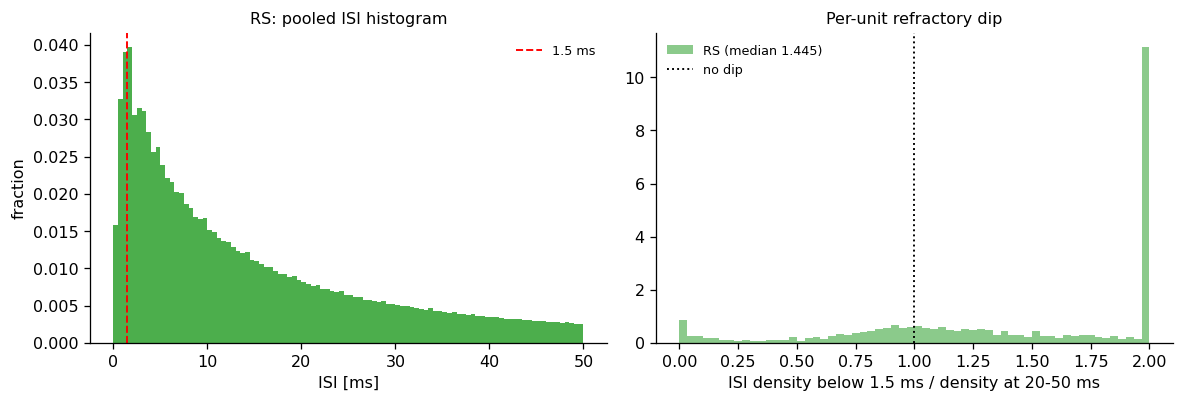

RS: median dip ratio 1.4448, 6.2% below 0.2, 71.5% show no dip at all


In [6]:
fig, axes = plt.subplots(1, len(DATA)+1, figsize=(5.2*(len(DATA)+1), 3.6), dpi=115)
axes = np.atleast_1d(axes)
for ax, (tr, h) in zip(axes, ISI.items()):
    d = DATA[tr]
    H = h[:len(d)]
    pooled = H.sum(axis=0)
    pooled = pooled / max(pooled.sum(), 1)
    ax.bar(ISI_CENTRES*1000, pooled, width=ISI_BIN_S*1000,
           color=COND_COL[tr], alpha=0.85)
    ax.axvline(1.5, color='r', ls='--', lw=1.2, label='1.5 ms')
    ax.set_xlabel('ISI [ms]'); ax.set_ylabel('fraction')
    ax.set_title(f'{tr}: pooled ISI histogram', fontsize=10)
    ax.legend(fontsize=8, frameon=False)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# per-unit refractory dip: density below 1.5 ms over density at 20-50 ms
ax = axes[-1]
for tr, h in ISI.items():
    d = DATA[tr]; H = h[:len(d)]
    m_rp  = ISI_CENTRES < 0.0015
    m_ref = (ISI_CENTRES >= 0.020) & (ISI_CENTRES < 0.050)
    dens_rp  = H[:, m_rp].sum(axis=1) / m_rp.sum()
    dens_ref = H[:, m_ref].sum(axis=1) / m_ref.sum()
    dip = np.divide(dens_rp, dens_ref, out=np.full_like(dens_rp, np.nan),
                    where=dens_ref > 0)
    d['isi_dip_ratio'] = dip
    v = pd.Series(dip).replace([np.inf,-np.inf], np.nan).dropna()
    ax.hist(np.clip(v, 0, 2), bins=60, alpha=0.55, density=True,
            color=COND_COL[tr], label=f'{tr} (median {v.median():.3f})')
ax.axvline(1.0, color='k', ls=':', lw=1.2, label='no dip')
ax.set_xlabel('ISI density below 1.5 ms / density at 20-50 ms')
ax.set_title('Per-unit refractory dip', fontsize=10)
ax.legend(fontsize=8, frameon=False)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

for tr, d in DATA.items():
    v = d['isi_dip_ratio'].replace([np.inf,-np.inf], np.nan).dropna()
    print(f'{tr}: median dip ratio {v.median():.4f}, '
          f'{100*(v < 0.2).mean():.1f}% below 0.2, '
          f'{100*(v > 1.0).mean():.1f}% show no dip at all')

In [7]:
# per class, since a genuinely bursty class will show a shallower dip
for tr, d in DATA.items():
    present = [c for c in FINAL_CLASSES if (d['final_class'] == c).any()]
    rows = []
    for cl in present:
        v = d.loc[d['final_class'] == cl,
                  'isi_dip_ratio'].replace([np.inf,-np.inf], np.nan).dropna()
        if len(v) < 10: continue
        rows.append({'class': CLASS_DICT[cl], 'n': len(v),
                     'median_dip': round(v.median(), 4),
                     'pct_no_dip': round(100*(v > 1.0).mean(), 1)})
    print(f'{tr}:')
    print(pd.DataFrame(rows).to_string(index=False))
    print()

RS:
  class   n  median_dip  pct_no_dip
 NarrBI 291      1.6443        71.5
  MedBI 788      1.7203        76.8
   Wide 927      1.2347        62.2
NarrTRI 212      1.7193        80.7
 MedTRI 265      1.4714        82.6
    Pos  91      1.4393        67.0



## 4. Independent validation

The criteria cannot validate themselves. This compares the units kept against
those removed, using only metrics that were **not** used as thresholds:

`wf_shape_pc1_modesep`, waveform shape heterogeneity, removed from the criteria
so it is now fully independent; `amp_mode_separation`, whether the amplitude
distribution splits in two; `atten_index`, whether short-interval spike pairs
show the amplitude attenuation a real burst produces; and `wf_corr_p05`, the
lower tail of the waveform-to-template correlation.

If the discarded units score worse on these, the filtering removed something
real rather than an arbitrary slice.

In [8]:
INDEPENDENT = ['wf_shape_pc1_modesep', 'amp_mode_separation',
               'atten_index', 'wf_corr_p05', 'amp_cv']
# direction in which a WORSE unit scores
WORSE_IS = {'wf_shape_pc1_modesep': 'higher', 'amp_mode_separation': 'higher',
            'atten_index': 'lower', 'wf_corr_p05': 'lower', 'amp_cv': 'higher'}

def load_all_metrics(type_rec, monkeys):
    dfs = []
    for m in monkeys:
        for date in P['dates'][m][type_rec]:
            p = f'{DF_FOLDER}/filter_metrics_{type_rec}/monkey{m}_all_arrays_date_{date}.pkl'
            try:
                with open(p,'rb') as f: dfs.append(pickle.load(f))
            except Exception:
                pass
    return pd.concat(dfs, ignore_index=True) if dfs else None

for tr, (monkeys, _) in CONDITIONS.items():
    if tr not in DATA: continue
    allm = load_all_metrics(tr, monkeys)
    if allm is None:
        print(f'{tr}: metrics not found'); continue
    kept_keys = set(map(tuple, DATA[tr][KEY].values))
    allm['kept'] = [tuple(r) in kept_keys for r in allm[KEY].values]
    print(f'===== {tr}: {int(allm["kept"].sum())} kept of {len(allm)} =====')
    rows = []
    for c in INDEPENDENT:
        if c not in allm.columns: continue
        a = allm.loc[allm['kept'], c].replace([np.inf,-np.inf], np.nan).dropna()
        b = allm.loc[~allm['kept'], c].replace([np.inf,-np.inf], np.nan).dropna()
        if len(a) < 20 or len(b) < 20: continue
        u = stats.mannwhitneyu(a, b)
        rb = 2*u.statistic/(len(a)*len(b)) - 1
        worse = WORSE_IS[c]
        good_sign = (rb < 0) if worse == 'higher' else (rb > 0)
        rows.append({'metric': c, 'worse_is': worse,
                     'median_kept': round(np.median(a), 4),
                     'median_removed': round(np.median(b), 4),
                     'rank_biserial': round(rb, 3),
                     'kept_better': good_sign, 'p': f'{u.pvalue:.1e}'})
    print(pd.DataFrame(rows).to_string(index=False))
    print()
    print('kept_better True means the retained units score in the direction')
    print('expected for cleaner units, on a measure not used to select them.')
    print()
    DATA[tr + '_all'] = allm

===== RS: 2574 kept of 11377 =====
              metric worse_is  median_kept  median_removed  rank_biserial  kept_better        p
wf_shape_pc1_modesep   higher       1.4246          1.4882         -0.202         True  7.5e-55
 amp_mode_separation   higher       1.4885          1.5729         -0.142         True  3.9e-28
         atten_index    lower       0.0030          0.0011          0.101         True  6.5e-15
         wf_corr_p05    lower       0.4947          0.4640          0.338         True 1.9e-150
              amp_cv   higher       0.1922          0.4353         -0.728         True  0.0e+00

kept_better True means the retained units score in the direction
expected for cleaner units, on a measure not used to select them.



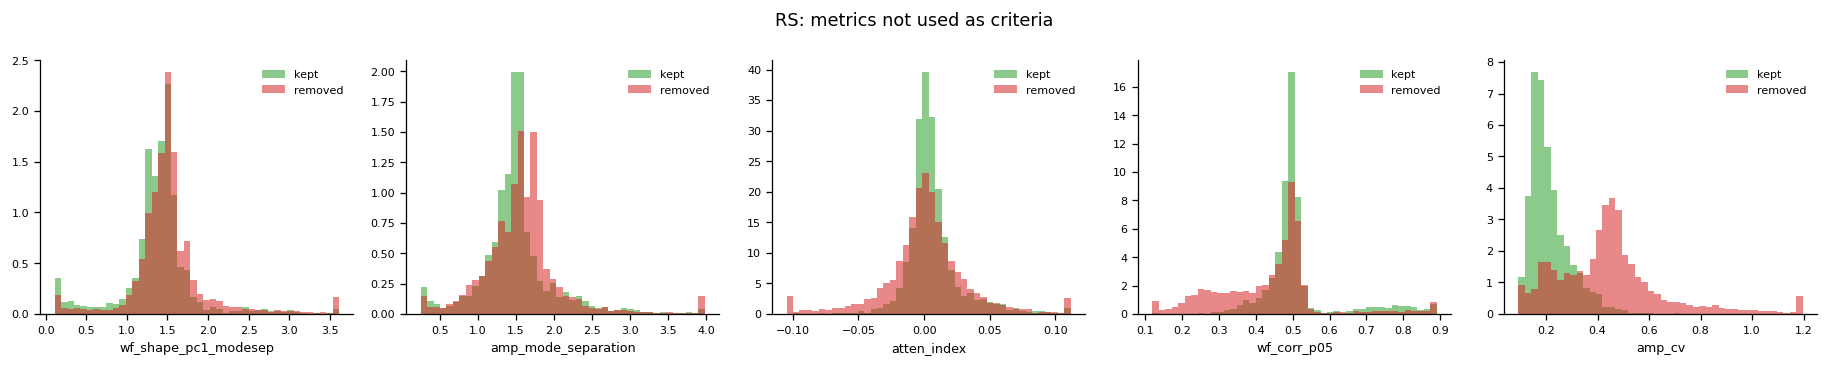

In [9]:
for tr in [t for t in CONDITIONS if t in DATA]:
    allm = DATA.get(tr + '_all')
    if allm is None: continue
    show = [c for c in INDEPENDENT if c in allm.columns]
    fig, axes = plt.subplots(1, len(show), figsize=(3.2*len(show), 3.2), dpi=115)
    axes = np.atleast_1d(axes)
    for ax, c in zip(axes, show):
        v = allm[c].replace([np.inf,-np.inf], np.nan)
        lo, hi = v.quantile(.01), v.quantile(.99)
        bins = np.linspace(lo, hi, 45)
        for lab, mask, col in [('kept', allm['kept'], 'tab:green'),
                               ('removed', ~allm['kept'], 'tab:red')]:
            vv = v[mask].dropna()
            if len(vv) > 20:
                ax.hist(np.clip(vv, lo, hi), bins=bins, alpha=0.55, density=True,
                        color=col, label=lab)
        ax.set_xlabel(c, fontsize=8); ax.tick_params(labelsize=7)
        ax.legend(fontsize=7, frameon=False)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    fig.suptitle(f'{tr}: metrics not used as criteria', fontsize=11)
    plt.tight_layout(); plt.show()

## 5. Are the waveform properties unimodal?

Within a class, the width and the first peak height should form one population.
Bimodality would mean the class still mixes distinct groups.

**A Gaussian mixture is not the right tool here.** On skewed or heavy-tailed
data a mixture adds components to approximate the shape rather than to find
clusters, and comparing by BIC then reports bimodality that is not there. Two
proper unimodality tests are used instead.

**Hartigan's dip test** measures the largest departure of the empirical
distribution from the closest unimodal one. It is nonparametric and is
unaffected by skew.

**Silverman's bandwidth test** finds the smallest kernel bandwidth at which the
density estimate becomes unimodal, then bootstraps from that density and asks
how often resampled data are multimodal.

Validated on known distributions: a skewed lognormal and a heavy-tailed t
distribution are correctly called unimodal by the dip test, where a mixture
model reports three components for both; genuine mixtures, including an unequal
80/20 split, are detected. A property is called multimodal only when both tests
agree, since they fail differently.

In [10]:
# Hartigan's dip test. Install once with: pip install diptest
try:
    import diptest
    HAVE_DIP = True
except ImportError:
    HAVE_DIP = False
    print('diptest not installed; the dip test will be skipped.')
    print('   pip install diptest')

from scipy.stats import gaussian_kde
from scipy.signal import argrelextrema


def _n_modes_kde(x, bw):
    """Number of local maxima of a Gaussian KDE at the given bandwidth."""
    k = gaussian_kde(x, bw_method=bw)
    g = np.linspace(x.min() - 0.5*x.std(), x.max() + 0.5*x.std(), 512)
    return len(argrelextrema(k(g), np.greater)[0])


def silverman_test(x, n_boot=150, seed=0, max_iter=40):
    """
    Silverman's bandwidth test for unimodality.

    The critical bandwidth is the smallest at which the density estimate is
    unimodal. Data are then resampled from the density at that bandwidth, and
    the proportion of resamples that are multimodal gives the p value. A small p
    rejects unimodality.
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 100 or np.std(x) == 0:
        return np.nan, np.nan
    lo, hi = 1e-3, 3.0
    for _ in range(max_iter):
        mid = 0.5*(lo + hi)
        if _n_modes_kde(x, mid) > 1:
            lo = mid
        else:
            hi = mid
    h = hi
    rng = np.random.default_rng(seed)
    n, sd = len(x), np.std(x)
    cnt = 0
    for _ in range(n_boot):
        y = x[rng.integers(0, n, n)] + h*sd*rng.normal(0, 1, n)
        y = x.mean() + (y - y.mean())/np.sqrt(1 + h**2)
        if _n_modes_kde(y, h) > 1:
            cnt += 1
    return (cnt + 1)/(n_boot + 1), h


def unimodality(v, n_boot=150, min_n=150):
    """Both tests on one property. Multimodal only when they agree."""
    x = np.asarray(v, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < min_n:
        return None
    d_p = diptest.diptest(x)[1] if HAVE_DIP else np.nan
    s_p, _ = silverman_test(x, n_boot=n_boot)
    if HAVE_DIP and np.isfinite(d_p) and np.isfinite(s_p):
        verdict = ('MULTIMODAL' if (d_p < 0.05 and s_p < 0.05)
                   else 'borderline' if (d_p < 0.05 or s_p < 0.05)
                   else 'unimodal')
    elif np.isfinite(s_p):
        verdict = 'multimodal?' if s_p < 0.05 else 'unimodal?'
    else:
        verdict = 'undetermined'
    return {'n': len(x),
            'dip_p': round(d_p, 4) if np.isfinite(d_p) else np.nan,
            'silverman_p': round(s_p, 4) if np.isfinite(s_p) else np.nan,
            'verdict': verdict}

diptest not installed; the dip test will be skipped.
   pip install diptest


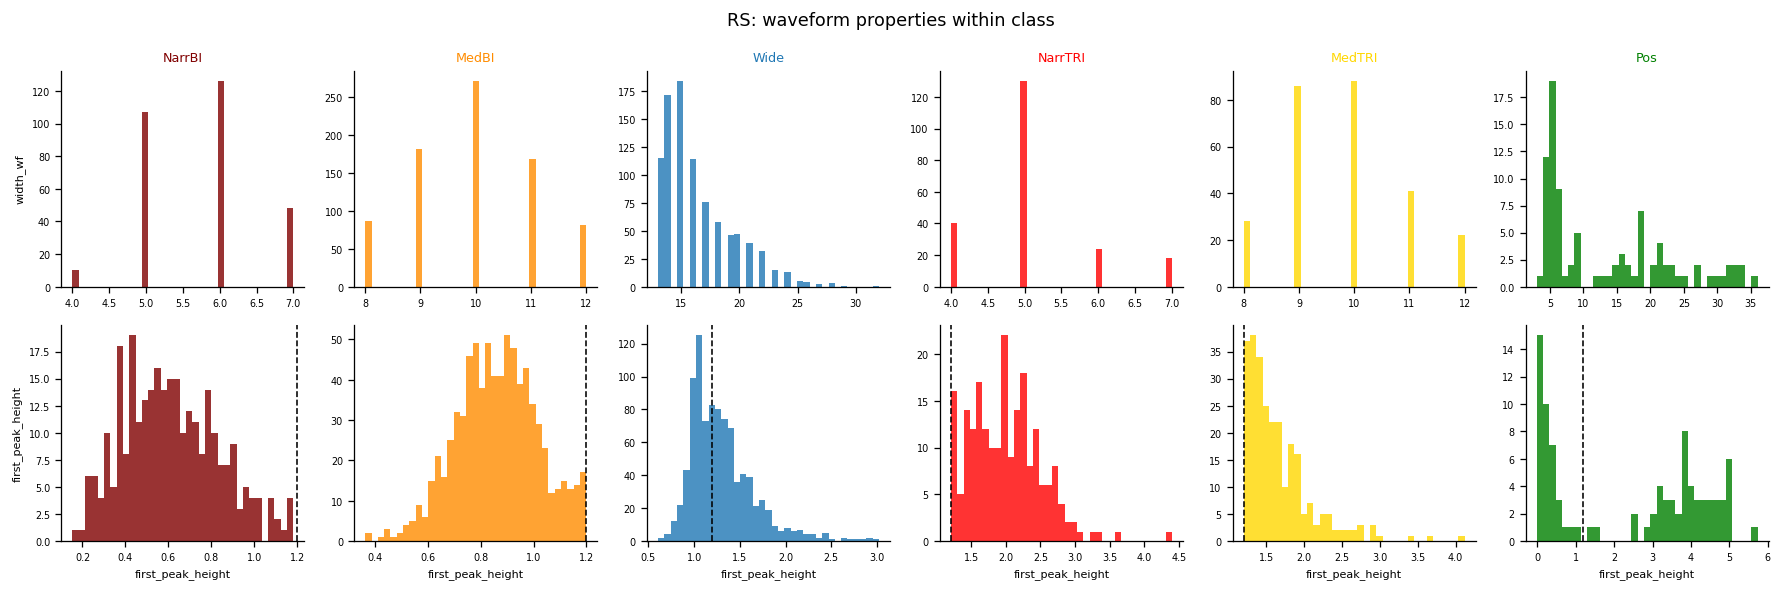

In [11]:
for tr in [t for t in CONDITIONS if t in DATA]:
    d = DATA[tr]
    present = [c for c in FINAL_CLASSES if (d['final_class'] == c).sum() > 30]
    fig, axes = plt.subplots(2, len(present), figsize=(2.6*len(present), 5.2),
                             dpi=115)
    axes = np.atleast_2d(axes)
    for j, cl in enumerate(present):
        sub = d[d['final_class'] == cl]
        for i, prop in enumerate(['width_wf', 'first_peak_height']):
            ax = axes[i, j]
            v = sub[prop].dropna()
            ax.hist(v, bins=35, color=CLASS_COLORS[cl], alpha=0.8)
            if prop == 'first_peak_height':
                ax.axvline(PEAK_HEIGHT, color='k', ls='--', lw=1)
            ax.set_xlabel(prop if i == 1 else '', fontsize=7)
            ax.tick_params(labelsize=6)
            if j == 0: ax.set_ylabel(prop, fontsize=7)
            if i == 0: ax.set_title(CLASS_DICT[cl], fontsize=8,
                                    color=CLASS_COLORS[cl])
            ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    fig.suptitle(f'{tr}: waveform properties within class', fontsize=11)
    plt.tight_layout(); plt.show()

## 6. Residual same-electrode duplication

Two surviving units on one electrode with a very high coincidence ratio would be
a duplicate that the threshold did not remove. Since a mutual pair is one neuron
split in two, both members surviving is the case to look for.

RS: coincidence ratio among survivors, median 1.78, p95 3.71, max 4.99
   above   3:   268 units (10.41%)
   above   5:     0 units (0.00%)
   above  10:     0 units (0.00%)
   above  25:     0 units (0.00%)
   electrodes carrying more than one surviving unit: 215 of 2320
   units on such electrodes: 469



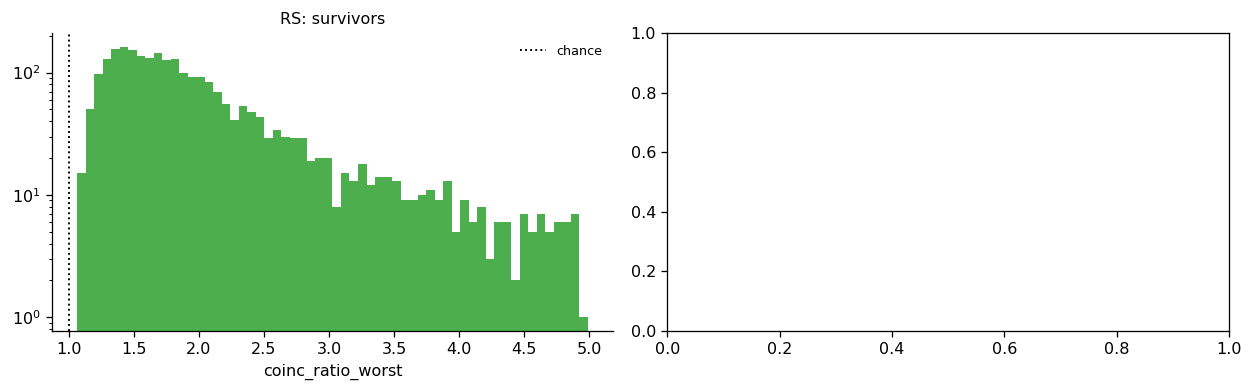

In [12]:
for tr in [t for t in CONDITIONS if t in DATA]:
    d = DATA[tr]
    if 'coinc_ratio_worst' not in d.columns: continue
    v = d['coinc_ratio_worst'].replace([np.inf,-np.inf], np.nan).dropna()
    print(f'{tr}: coincidence ratio among survivors, '
          f'median {v.median():.2f}, p95 {v.quantile(.95):.2f}, max {v.max():.2f}')
    for th in [3, 5, 10, 25]:
        n_above = int((v > th).sum())
        print(f'   above {th:3d}: {n_above:5d} units '
              f'({100*(v > th).mean():.2f}%)')
    # units sharing an electrode
    g = d.groupby(['monkey','date','array','Electrode_ID']).size()
    print(f'   electrodes carrying more than one surviving unit: '
          f'{int((g > 1).sum())} of {len(g)}')
    print(f'   units on such electrodes: {int(g[g > 1].sum())}')
    print()

fig, axes = plt.subplots(1, len(DATA), figsize=(5.5*len(DATA), 3.5), dpi=115)
axes = np.atleast_1d(axes)
for ax, tr in zip(axes, [t for t in CONDITIONS if t in DATA]):
    d = DATA[tr]
    v = d['coinc_ratio_worst'].replace([np.inf,-np.inf], np.nan).dropna()
    ax.hist(np.clip(v, 0, 30), bins=60, color=COND_COL[tr], alpha=0.85)
    ax.axvline(1, color='k', ls=':', lw=1.2, label='chance')
    ax.set_yscale('log'); ax.set_xlabel('coinc_ratio_worst')
    ax.set_title(f'{tr}: survivors', fontsize=10)
    ax.legend(fontsize=8, frameon=False)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

## 7. Per-class summary

In [13]:
for tr in [t for t in CONDITIONS if t in DATA]:
    d = DATA[tr]
    rows = []
    for cl in FINAL_CLASSES:
        sub = d[d['final_class'] == cl]
        if not len(sub): continue
        r = {'class': CLASS_DICT[cl], 'n': len(sub),
             'pct': round(100*len(sub)/len(d), 1)}
        for c, lab in [('FR_computed','FR'), ('width_wf','width'),
                       ('viol_ratio_1p5ms','viol'), ('isi_dip_ratio','dip'),
                       ('wf_snr_computed','SNR'),
                       ('wf_shape_pc1_modesep','shape')]:
            if c in sub.columns:
                r[lab] = round(sub[c].replace([np.inf,-np.inf], np.nan).median(), 3)
        rows.append(r)
    print(f'===== {tr} =====')
    print(pd.DataFrame(rows).to_string(index=False))
    print()

===== RS =====
  class   n  pct     FR  width  viol   dip   SNR  shape
 NarrBI 291 11.3 15.995    6.0 1.145 1.644 4.791  1.302
  MedBI 788 30.6 22.441   10.0 0.961 1.720 4.275  1.426
   Wide 927 36.0 20.747   15.0 0.691 1.235 4.198  1.445
NarrTRI 212  8.2 14.557    5.0 1.131 1.719 5.208  1.363
 MedTRI 265 10.3 13.426   10.0 1.114 1.471 4.486  1.391
    Pos  91  3.5 12.858    9.0 0.990 1.439 5.416  1.504



## 8. Export

In [14]:
OUT = f'{DF_FOLDER}/filtered_validation'
ensure_dir_exists(OUT)
for tr in [t for t in CONDITIONS if t in DATA]:
    d = DATA[tr]
    cols = [c for c in d.columns if c not in ('avg_wf','avg_wf_zscored')]
    d[cols].to_csv(f'{OUT}/classified_units_{tr}.csv', index=False)
    d[KEY + ['final_class','width_wf_class','wf_direction','width_wf',
             'first_peak_height','avg_wf','avg_wf_zscored']].to_pickle(
        f'{OUT}/classified_units_{tr}.pkl')
    print(f'{tr}: {len(d)} classified units written')
print()
print('saved to', OUT)

RS: 2574 classified units written

saved to /CSNG/studekat/ripple_paper_clean_copy/dataframes/filtered_validation


## How to read this

**Section 3 is the population-level test.** A pooled interspike interval
histogram that rises from near zero, and a per-unit dip ratio concentrated well
below 1, indicate a population behaving like single units. A substantial
fraction with no dip at all would mean contamination survived.

**Section 4 carries the most weight.** The criteria cannot validate themselves,
so only metrics that were not thresholded are used. If the removed units score
worse on shape heterogeneity, amplitude splitting, burst attenuation and
waveform consistency, the filtering removed something real. If they score the
same, the criteria removed an arbitrary slice.

**Section 5 uses proper unimodality tests, not a mixture model.** A mixture will
split a skewed or heavy-tailed unimodal distribution, reporting structure that
is not there; on synthetic data a lognormal and a t distribution were both
assigned three components. Hartigan's dip test and Silverman's bandwidth test
are nonparametric and unaffected by skew, and a property is called multimodal
only when both agree. Note that width across all units should be multimodal by
construction, since the classes are defined by it; the informative rows are
those within a single class.

**Section 6 is the residual check.** A mutual coincidence pair is one neuron in
two clusters, so both members surviving means a duplicate remains. If many
electrodes carry several surviving units with high coincidence, the coincidence
threshold is too loose.

**On the classification.** It uses the project's own functions, so the six
classes match the rest of the analysis exactly. The z-scored waveform stored by
the filtering script is the same quantity their
`aux_add_zscored_avg_waveform` produces: scipy's zscore applied to the averaged
waveform.